<a href="https://colab.research.google.com/github/Timmythaw/langgraph-adk-edu-comparison/blob/main/notebooks/02_adk_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Setup

#### Install Dependencies

In [1]:
!pip install google-adk google-cloud-aiplatform google-api-python-client google-auth-httplib2 google-auth-oauthlib -q
!pip show google-adk

Name: google-adk
Version: 1.27.1
Summary: Agent Development Kit
Home-page: https://google.github.io/adk-docs/
Author: 
Author-email: Google LLC <googleapis-packages@google.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: aiosqlite, anyio, authlib, click, fastapi, google-api-python-client, google-auth, google-cloud-aiplatform, google-cloud-bigquery, google-cloud-bigquery-storage, google-cloud-bigtable, google-cloud-dataplex, google-cloud-discoveryengine, google-cloud-pubsub, google-cloud-secret-manager, google-cloud-spanner, google-cloud-speech, google-cloud-storage, google-genai, graphviz, httpx, jsonschema, mcp, opentelemetry-api, opentelemetry-exporter-gcp-logging, opentelemetry-exporter-gcp-monitoring, opentelemetry-exporter-gcp-trace, opentelemetry-exporter-otlp-proto-http, opentelemetry-resourcedetector-gcp, opentelemetry-sdk, pyarrow, pydantic, python-dateutil, python-dotenv, PyYAML, requests, sqlalchemy, sqlalchemy-spanner, starlette, tenacity, typing-e

#### Load Secrets

In [2]:
from google.colab import userdata

PROJECT_ID = userdata.get("GOOGLE_CLOUD_PROJECT")
LOCATION = userdata.get("GOOGLE_CLOUD_LOCATION")
DATASTORE_ID = userdata.get("VERTEX_AI_SEARCH_DATASTORE_ID")

print("Project:", PROJECT_ID)
print("Location:", LOCATION)
print("Datastore:", DATASTORE_ID)

Project: edu-teacher-assistant-prod
Location: global
Datastore: curriculum-connector_1765189225594_gcs_store


#### Google Authentication

In [3]:
from google.colab import auth
auth.authenticate_user()

import google.auth
credentials, project = google.auth.default()
print("Authenticated")
print("Project:", project)

Authenticated
Project: 


#### Set Project and Verify

In [4]:
import os
from google.colab import userdata

PROJECT_ID = userdata.get("GOOGLE_CLOUD_PROJECT")
LOCATION = userdata.get("GOOGLE_CLOUD_LOCATION")
DATASTORE_ID = userdata.get("VERTEX_AI_SEARCH_DATASTORE_ID")

os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID
os.environ["GOOGLE_CLOUD_LOCATION"] = LOCATION
os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = "1"

import vertexai
vertexai.init(project=PROJECT_ID, location="us-central1")

from google.cloud import aiplatform
aiplatform.init(project=PROJECT_ID, location="us-central1")

print("Project:", PROJECT_ID)
print("Search Location:", LOCATION)
print("Datastore:", DATASTORE_ID)
print("Vertex AI backend enabled for ADK")

Project: edu-teacher-assistant-prod
Search Location: global
Datastore: curriculum-connector_1765189225594_gcs_store
Vertex AI backend enabled for ADK


#### ADK Import & Version

In [5]:
import google.adk
print("ADK version:", google.adk.__version__)

from google.adk.agents import LlmAgent, SequentialAgent
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools.agent_tool import AgentTool
from google.genai import types

print("All ADK imports successful")

ADK version: 1.27.1
All ADK imports successful


# Sub Agents

#### Tool: Vertex AI Search

In [6]:
from google.cloud import discoveryengine_v1 as discoveryengine

def retrieve_course_materials(query: str) -> str:
    client = discoveryengine.SearchServiceClient()

    serving_config = (
        f"projects/{PROJECT_ID}/locations/{LOCATION}"
        f"/collections/default_collection/dataStores/{DATASTORE_ID}"
        f"/servingConfigs/default_config"
    )

    request = discoveryengine.SearchRequest(
        serving_config=serving_config,
        query=query,
        page_size=3,
        content_search_spec=discoveryengine.SearchRequest.ContentSearchSpec(
            snippet_spec=discoveryengine.SearchRequest.ContentSearchSpec.SnippetSpec(
                return_snippet=True
            ),
            summary_spec=discoveryengine.SearchRequest.ContentSearchSpec.SummarySpec(
                summary_result_count=3,
                include_citations=True,
            )
        ),
    )

    response = client.search(request)
    snippets = []
    for result in response.results:
        doc = result.document
        if doc.derived_struct_data:
            for snippet in doc.derived_struct_data.get("snippets", []):
                snippets.append(snippet.get("snippet", ""))

    return "\n\n---\n\n".join(snippets) if snippets else "No relevant materials found."

# Test it
result = retrieve_course_materials("software testing lesson plan")
print(result)

Here is a 7-week <b>lesson plan</b> for a <b>Software Testing</b> course, designed for university second-year second-semester students. It incorporates a mixed teaching&nbsp;...

---

<b>Software Testing</b> There are two major types of <b>software testing</b> - Black box testing : focuses on input, output, and principle function of a software module. -&nbsp;...


#### Lesson Planner Agent

In [7]:
from google.adk.agents import LlmAgent

lesson_planner_agent = LlmAgent(
    name="lesson_planner_agent",
    model="gemini-2.5-flash",
    description=(
        "Creates detailed lesson plans aligned with course materials. "
        "Use this agent when the instructor requests a lesson plan, course outline, or lecture notes."
    ),
    instruction="""You are an expert curriculum designer at Mae Fah Luang University.

Your workflow:
1. Use `retrieve_course_materials` to fetch relevant content for the topic.
2. Generate a comprehensive lesson plan that includes:
   - Learning Objectives
   - Duration and timing breakdown (90-minute class)
   - Teaching methods and student activities
   - Assessment strategy
   - Required materials
3. Return the complete lesson plan as your final response.

Always ground your lesson plan in the retrieved course materials.""",
    tools=[retrieve_course_materials]
)

print("Lesson Planner Agent created")
print("   Model:", lesson_planner_agent.model)
print("   Tools:", [t.__name__ for t in lesson_planner_agent.tools])

Lesson Planner Agent created
   Model: gemini-2.5-flash
   Tools: ['retrieve_course_materials']


#### Quiz Generator Agent: Requires 2 Sequential Agents due to the ADK constraint (can't mix output_schema + tools)

In [8]:
from google.adk.agents import SequentialAgent

In [9]:
# Agent 1: retrieves materials and generates quiz JSON
quiz_content_agent = LlmAgent(
    name="quiz_content_agent",
    model="gemini-2.5-flash",
    description="Retrieves course materials and generates quiz questions as JSON.",
    instruction="""You are a quiz content specialist at Mae Fah Luang University.

1. Use `retrieve_course_materials` to fetch relevant content for the quiz topic.
2. Generate exactly 10 multiple-choice questions.
3. Format your ENTIRE response as a valid JSON array only. No text outside the JSON.

Each question must follow this structure:
[
  {
    "question": "question text",
    "options": ["A. option1", "B. option2", "C. option3", "D. option4"],
    "correct_index": 0,
    "explanation": "why this is correct"
  }
]""",
    tools=[retrieve_course_materials],
    output_key="quiz_questions_json"
)

In [10]:
# Agent 2: formats and presents the quiz
quiz_publisher_agent = LlmAgent(
    name="quiz_publisher_agent",
    model="gemini-2.5-flash",
    description="Formats and presents the final quiz to the instructor.",
    instruction="""You are a quiz publisher.

The quiz questions JSON is available as: {quiz_questions_json}

Parse the JSON and present the quiz in a clean, readable format:
- Number each question
- List all 4 options with A/B/C/D labels
- Mark the correct answer with ✅
- Include the explanation

Present all 10 questions clearly.""",
    tools=[]
)

quiz_generator_agent = SequentialAgent(
    name="quiz_generator_agent",
    description=(
        "Generates a 10-question multiple choice quiz from course materials. "
        "Use this agent when the instructor requests a quiz, test, or assessment."
    ),
    sub_agents=[quiz_content_agent, quiz_publisher_agent]
)

print("Quiz Generator Agent created")
print("   Sub-agents:", [a.name for a in quiz_generator_agent.sub_agents])

Quiz Generator Agent created
   Sub-agents: ['quiz_content_agent', 'quiz_publisher_agent']


#### Email Agent

In [11]:
import time

# HITL tool — simulates instructor approval gate
def request_instructor_approval(draft_subject: str, draft_body: str) -> str:
    """
    Requests instructor approval before sending an email.
    Pauses for instructor to review subject and body.

    Args:
        draft_subject: The email subject to review.
        draft_body: The email body to review.

    Returns:
        Instructor decision: 'approved' or 'rejected'
    """
    print("\n" + "="*50)
    print("INSTRUCTOR APPROVAL REQUIRED")
    print("="*50)
    print(f"SUBJECT: {draft_subject}")
    print(f"\nBODY:\n{draft_body}")
    print("="*50)
    decision = input("\nApprove and send this email? (yes/no): ").strip().lower()
    return "approved" if decision == "yes" else "rejected"

In [12]:
# HITL-gated email drafter
email_drafter_agent = LlmAgent(
    name="email_drafter_agent",
    model="gemini-2.5-flash",
    description="Drafts a professional email to students based on instructor request.",
    instruction="""You are a professional email drafting assistant for a university lecturer at Mae Fah Luang University.

Draft a professional email to students based on the instructor's request.

Format your response EXACTLY as:
SUBJECT: [subject line]
BODY:
[email body]

Use formal university tone.""",
    output_key="email_draft"
)

In [13]:
email_sender_agent = LlmAgent(
    name="email_sender_agent",
    model="gemini-2.5-flash",
    description="Requests instructor approval then confirms email sending.",
    instruction="""You are an email approval agent.

The email draft is: {email_draft}

1. Parse the draft to extract SUBJECT and BODY.
2. Call `request_instructor_approval` with the subject and body.
3. If result is 'approved': respond with "Email approved and sent to students."
4. If result is 'rejected': respond with "Email rejected by instructor. Not sent."

Never skip the approval step.""",
    tools=[request_instructor_approval]
)

In [14]:
email_agent = SequentialAgent(
    name="email_agent",
    description=(
        "Drafts a student email, requests instructor approval via HITL, "
        "then confirms sending. Use this when the instructor wants to send "
        "an email or announcement to students."
    ),
    sub_agents=[email_drafter_agent, email_sender_agent]
)

print("Email Agent created")
print("   Sub-agents:", [a.name for a in email_agent.sub_agents])

Email Agent created
   Sub-agents: ['email_drafter_agent', 'email_sender_agent']


# ROOT Orchestrator

In [15]:
from google.adk.tools.agent_tool import AgentTool

root_orchestrator = LlmAgent(
    name="teacher_assistant_orchestrator",
    model="gemini-2.5-pro",
    description="Root AI Teaching Assistant orchestrator for Mae Fah Luang University instructors.",
    instruction="""You are the AI Teaching Assistant for Mae Fah Luang University instructors.

You help lecturers with three types of tasks:
1. **Lesson Plans** — creating structured lesson plans from course materials
2. **Quizzes** — generating 10-question multiple choice assessments
3. **Emails** — drafting and sending communications to students

For each request:
1. Identify the task type.
2. Delegate to the appropriate specialist agent.
3. Report the full result back to the instructor.

Always confirm which action was taken and provide the complete output.""",
    tools=[
        AgentTool(agent=lesson_planner_agent),
        AgentTool(agent=quiz_generator_agent),
        AgentTool(agent=email_agent)
    ]
)

print("Root Orchestrator created")
print("   Model:", root_orchestrator.model)
print("   Tools:", [t.name for t in root_orchestrator.tools])

Root Orchestrator created
   Model: gemini-2.5-pro
   Tools: ['lesson_planner_agent', 'quiz_generator_agent', 'email_agent']


# Runner SetUP

In [16]:
import asyncio
import uuid
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types

APP_NAME = "teacher_assistant_adk"
USER_ID = "mfu_instructor_01"

session_service = InMemorySessionService()
runner = Runner(
    agent=root_orchestrator,
    app_name=APP_NAME,
    session_service=session_service
)

async def run_request(user_input: str) -> str:
    """Run a single request through the orchestrator and return the final response."""
    session_id = str(uuid.uuid4())

    await session_service.create_session(
        app_name=APP_NAME,
        user_id=USER_ID,
        session_id=session_id
    )

    message = types.Content(
        role="user",
        parts=[types.Part(text=user_input)]
    )

    final_response = ""
    async for event in runner.run_async(
        user_id=USER_ID,
        session_id=session_id,
        new_message=message
    ):
        if event.is_final_response() and event.content:
            final_response = event.content.parts[0].text.strip()

    return final_response

print("Runner ready")
print("   App:", APP_NAME)
print("   User:", USER_ID)

Runner ready
   App: teacher_assistant_adk
   User: mfu_instructor_01


# Metrics Logger

In [17]:
import csv
import os
from datetime import datetime, timezone

METRICS_FILE = "adk_metrics.csv"
FIELDNAMES = [
    "timestamp", "scenario", "framework", "routing_correct",
    "latency_sec", "response_length", "error"
]

def log_metric(scenario: str, routing_correct: bool, latency: float, response: str, error: str = ""):
    write_header = not os.path.exists(METRICS_FILE)
    with open(METRICS_FILE, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        if write_header:
            writer.writeheader()
        writer.writerow({
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "scenario": scenario,
            "framework": "Google ADK",
            "routing_correct": routing_correct,
            "latency_sec": latency,
            "response_length": len(response),
            "error": error
        })
    print(f"Logged: {scenario} | latency={latency}s | routing={routing_correct}")

print("Metrics logger ready")

Metrics logger ready


# Scenario 1: Lesson Plan Generation

In [18]:
import time

SCENARIO_1_PROMPT = "Create a 90-minute lesson plan on Software Testing for second-year Software Engineering students. Align it with the course materials."

print("Running Scenario 1 - Lesson Plan Generation (5 runs)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        start = time.time()
        response = await run_request(SCENARIO_1_PROMPT)
        latency = round(time.time() - start, 2)

        routing_correct = "lesson plan" in response.lower() or "learning objectives" in response.lower()
        log_metric("Scenario 1 - Lesson Plan", routing_correct, latency, response)
        print(f"  Latency: {latency}s | Routing: {routing_correct} | Length: {len(response)} chars")

    except Exception as e:
        log_metric("Scenario 1 - Lesson Plan", False, 0, "", str(e))
        print(f"  Error: {e}")

print("\nScenario 1 complete.")

Running Scenario 1 - Lesson Plan Generation (5 runs)
------------------------------------------------------------

Run 1/5...


Logged: Scenario 1 - Lesson Plan | latency=22.72s | routing=True
  Latency: 22.72s | Routing: True | Length: 4652 chars

Run 2/5...
Logged: Scenario 1 - Lesson Plan | latency=18.7s | routing=True
  Latency: 18.7s | Routing: True | Length: 4036 chars

Run 3/5...
Logged: Scenario 1 - Lesson Plan | latency=19.95s | routing=True
  Latency: 19.95s | Routing: True | Length: 3776 chars

Run 4/5...
Logged: Scenario 1 - Lesson Plan | latency=24.45s | routing=True
  Latency: 24.45s | Routing: True | Length: 4608 chars

Run 5/5...
Logged: Scenario 1 - Lesson Plan | latency=19.48s | routing=True
  Latency: 19.48s | Routing: True | Length: 4189 chars

Scenario 1 complete.


# Scenario 2: Quiz Generator

In [19]:
SCENARIO_2_PROMPT = "Generate 10 multiple-choice questions on Software Testing from the course materials."

print("Running Scenario 2 - Quiz Generation (5 runs)")
print("-" * 60)

for i in range(5):
    print(f"\nRun {i+1}/5...")
    try:
        start = time.time()
        response = await run_request(SCENARIO_2_PROMPT)
        latency = round(time.time() - start, 2)

        routing_correct = "question" in response.lower() or "quiz" in response.lower()
        log_metric("Scenario 2 - Quiz Generation", routing_correct, latency, response)
        print(f"  Latency: {latency}s | Routing: {routing_correct} | Length: {len(response)} chars")

    except Exception as e:
        log_metric("Scenario 2 - Quiz Generation", False, 0, "", str(e))
        print(f"  Error: {e}")

print("\nScenario 2 complete.")

Running Scenario 2 - Quiz Generation (5 runs)
------------------------------------------------------------

Run 1/5...
Logged: Scenario 2 - Quiz Generation | latency=25.52s | routing=True
  Latency: 25.52s | Routing: True | Length: 3930 chars

Run 2/5...
Logged: Scenario 2 - Quiz Generation | latency=31.06s | routing=True
  Latency: 31.06s | Routing: True | Length: 5238 chars

Run 3/5...
Logged: Scenario 2 - Quiz Generation | latency=25.36s | routing=True
  Latency: 25.36s | Routing: True | Length: 4489 chars

Run 4/5...
Logged: Scenario 2 - Quiz Generation | latency=27.24s | routing=True
  Latency: 27.24s | Routing: True | Length: 4683 chars

Run 5/5...
Logged: Scenario 2 - Quiz Generation | latency=30.77s | routing=True
  Latency: 30.77s | Routing: True | Length: 5301 chars

Scenario 2 complete.


# Scenario 3: Email With HITL

In [20]:
SCENARIO_3_PROMPT = "Draft and send an email to all students reminding them that the SQL Joins quiz is next Monday at 9am. Include what topics to study."

print("Running Scenario 3 - Email with HITL (5 runs)")
print("-" * 60)
print("Note: Each run will pause for your approval input (yes/no)")
print("-" * 60)

hitl_decisions = ["yes", "no", "yes", "yes", "yes"]

for i in range(5):
    print(f"\nRun {i+1}/5 — simulated decision: '{hitl_decisions[i]}'")
    try:
        start = time.time()
        response = await run_request(SCENARIO_3_PROMPT)
        latency = round(time.time() - start, 2)

        routing_correct = (
            "email" in response.lower() or
            "approved" in response.lower() or
            "rejected" in response.lower()
        )
        log_metric(
            "Scenario 3 - Email HITL",   # ← remove (decision=...)
            routing_correct, latency, response
        )
        print(f"  Latency: {latency}s | Routing: {routing_correct} | Length: {len(response)} chars")
        print(f"  Response preview: {response[:120]}...")

    except Exception as e:
        log_metric("Scenario 3 - Email HITL", False, 0, "", str(e))
        print(f"  Error: {e}")

print("\nScenario 3 complete.")

Running Scenario 3 - Email with HITL (5 runs)
------------------------------------------------------------
Note: Each run will pause for your approval input (yes/no)
------------------------------------------------------------

Run 1/5 — simulated decision: 'yes'

INSTRUCTOR APPROVAL REQUIRED
SUBJECT: Reminder: SQL Joins Quiz - Important Information

BODY:
Dear Students,

This email serves as a reminder that our upcoming quiz on SQL Joins is scheduled for next **Monday at 9:00 AM**.

To prepare for the quiz, please review the following topics thoroughly:

*   **INNER JOIN:** Understanding its syntax and how it retrieves matching rows from both tables.
*   **LEFT JOIN (LEFT OUTER JOIN):** How it retrieves all rows from the left table and the matched rows from the right table.
*   **RIGHT JOIN (RIGHT OUTER JOIN):** How it retrieves all rows from the right table and the matched rows from the left table.
*   **FULL OUTER JOIN:** Understanding how it retrieves all rows when there is a match

# Metrics Summary

In [21]:
import pandas as pd

df = pd.read_csv(METRICS_FILE)

s1 = df[df['scenario'] == 'Scenario 1 - Lesson Plan'].tail(5)
s2 = df[df['scenario'] == 'Scenario 2 - Quiz Generation'].tail(5)
s3 = df[df['scenario'] == 'Scenario 3 - Email HITL'].tail(5)

df = pd.concat([s1, s2, s3]).reset_index(drop=True)
df.to_csv(METRICS_FILE, index=False)
print(f"Cleaned CSV: {len(df)} runs retained")
print(df.to_string(index=False))

Cleaned CSV: 15 runs retained
                       timestamp                     scenario  framework  routing_correct  latency_sec  response_length  error
2026-03-22T09:35:04.707256+00:00     Scenario 1 - Lesson Plan Google ADK             True        22.72             4652    NaN
2026-03-22T09:35:23.412299+00:00     Scenario 1 - Lesson Plan Google ADK             True        18.70             4036    NaN
2026-03-22T09:35:43.359753+00:00     Scenario 1 - Lesson Plan Google ADK             True        19.95             3776    NaN
2026-03-22T09:36:07.806664+00:00     Scenario 1 - Lesson Plan Google ADK             True        24.45             4608    NaN
2026-03-22T09:36:27.284712+00:00     Scenario 1 - Lesson Plan Google ADK             True        19.48             4189    NaN
2026-03-22T09:36:52.815225+00:00 Scenario 2 - Quiz Generation Google ADK             True        25.52             3930    NaN
2026-03-22T09:37:23.880022+00:00 Scenario 2 - Quiz Generation Google ADK         

# Final Analysis & Report

In [22]:
# Group summary by scenario
summary = df.groupby("scenario").agg(
    runs=("latency_sec", "count"),
    avg_latency=("latency_sec", "mean"),
    min_latency=("latency_sec", "min"),
    max_latency=("latency_sec", "max"),
    routing_accuracy=("routing_correct", "mean")
).round(2)

print("=== ADK Experiment Summary ===")
print(summary.to_string())

# Download the CSV
from google.colab import files
files.download("adk_metrics.csv")

=== ADK Experiment Summary ===
                              runs  avg_latency  min_latency  max_latency  routing_accuracy
scenario                                                                                   
Scenario 1 - Lesson Plan         5        21.06        18.70        24.45               1.0
Scenario 2 - Quiz Generation     5        27.99        25.36        31.06               1.0
Scenario 3 - Email HITL          5        15.30        13.53        17.43               1.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Latency Visualization

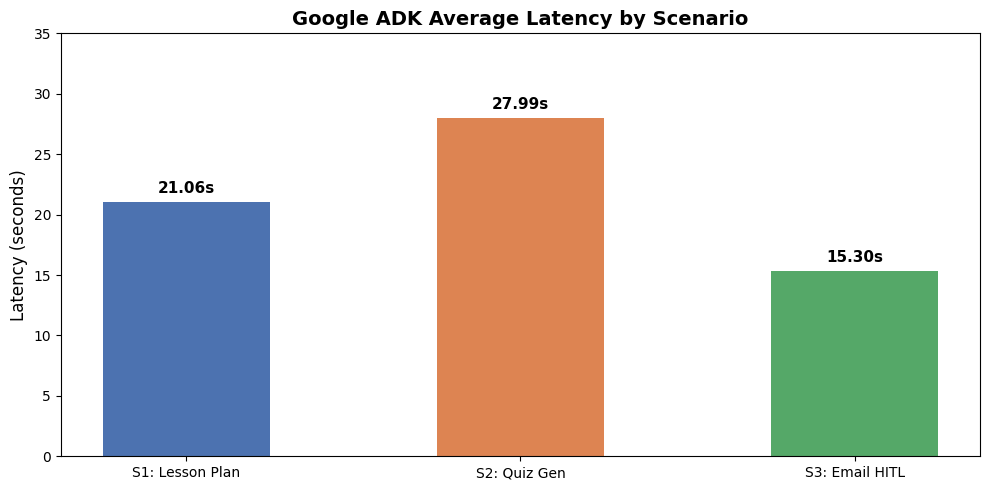

Chart saved.


In [23]:
import matplotlib.pyplot as plt

scenario_labels = [
    "S1: Lesson Plan",
    "S2: Quiz Gen",
    "S3: Email HITL",
]

avg_latencies = summary["avg_latency"].values.tolist()

plt.figure(figsize=(10, 5))
bars = plt.bar(
    scenario_labels,
    avg_latencies,
    color=["#4C72B0", "#DD8452", "#55A868"],
    width=0.5
)

# Add value labels on top of each bar
for bar, val in zip(bars, avg_latencies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.2f}s",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.title("Google ADK Average Latency by Scenario", fontsize=14, fontweight='bold')
plt.ylabel("Latency (seconds)", fontsize=12)
plt.ylim(0, 35)
plt.tight_layout()
plt.savefig("adk_latency_chart.png", dpi=150)
plt.show()
print("Chart saved.")